# Classic NLP vs LLMs: Text Classification, Topic Modelling, and the Cost-Quality Pareto

**The problem.** A platform team has been asked to ship two NLP capabilities by end of quarter: (a) **categorise incoming text** into pre-defined buckets (an existing classification job that runs nightly over millions of documents), and (b) **surface latent themes** for a weekly editorial dashboard.  The team's GenAI infrastructure works, but **inference cost dominates the unit economics**: at the per-call price of an LLM API, the nightly classification job alone would cost more than the engineer running it.  The deliverable is therefore not "the highest-accuracy model"; it is **a head-to-head benchmark of classical and modern approaches with deployment-cost numbers**, so the team can pick the *right* point on the cost-quality curve for each task.

**The data.** **20 Newsgroups** — the canonical text-classification benchmark, ~18,000 hand-labelled posts across 20 topical categories, sklearn-built-in (`fetch_20newsgroups`).  Real text, no auth, deterministic split.  20 hand-labelled categories also give us **ground truth for topic-modelling quality** (NMI, homogeneity, completeness vs the labels) — usually impossible on real corpora.

**The approach.**

1. **Data + EDA** — corpus stats, class balance, document-length distribution, vocabulary; the noisy, heavy-tailed reality of real text.
2. **Three text representations**, each with a clear cost profile:
   - **TF-IDF** — sparse, high-dim, near-zero per-document inference cost.
   - **LSA** (`TruncatedSVD` on TF-IDF) — dense, low-dim, classical-as-it-gets.
   - **Sentence embeddings** (sentence-transformers `MiniLM-L6`) — dense, semantic, modern.
3. **Five classification approaches** trained on the same `train/test` split:
   - **TF-IDF + Linear SVM** — the classical bar.
   - **TF-IDF + Logistic Regression** — interpretable baseline.
   - **TF-IDF + LightGBM** — gradient boosting on sparse text.
   - **MiniLM + LightGBM** — modern dense embeddings, classical classifier.
   - **Fine-tuned DistilBERT** — frontier transformer (CPU-only, sub-corpus for speed).
4. **Cost-quality leaderboard** — macro-F1, per-class F1, plus **train time, single-document inference latency (µs), bytes on disk** so the operational cost / accuracy trade-off is visible at a glance.
5. **Three topic-modelling approaches**:
   - **LDA** (Latent Dirichlet Allocation) — the classical probabilistic generative model.
   - **NMF** on TF-IDF — matrix-factorisation, classical, often competitive with LDA at lower compute.
   - **BERTopic-style** — sentence-embeddings + KMeans + class-based TF-IDF (`c-TF-IDF`) for topic words; we hand-roll instead of pulling the heavy `bertopic` dependency.
6. **Topic-quality scoring** — UMass coherence, NMI / homogeneity / completeness vs the 20 ground-truth labels, plus a topic-word inspection table.
7. **Embedding-space utilities** — semantic search demo, document clustering, **cost-quality Pareto front**.
8. **Decision memo** — a precise "use X when Y" rules table with the cost numbers as evidence.
9. **Production hygiene** — persisted TF-IDF + LightGBM + sentence-encoder reference, inference-parity check, model card.

**Audience.** ML engineers building production NLP, platform teams choosing between classical and LLM stacks, anyone responsible for the cost-per-inference column on a model card.

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio; paths computed relative to the notebook.  All artefacts live under `notebooks/artifacts/classic_nlp/`.  The 20 Newsgroups corpus is cached in sklearn's standard cache (`~/scikit_learn_data/`); MiniLM weights are cached by `sentence-transformers`.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import re
import time
import warnings
from collections import Counter
from dataclasses import dataclass

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, completeness_score, confusion_matrix,
                              f1_score, homogeneity_score, normalized_mutual_info_score)
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "classic_nlp_text_classification_topics.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "classic_nlp"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"NB_DIR     : {NB_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"torch      : {torch.__version__}")
print(f"lightgbm   : {lgb.__version__}")

NB_DIR     : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR   : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\classic_nlp
torch      : 2.11.0+cpu
lightgbm   : 4.6.0


## 1. 20 Newsgroups — load + EDA

We strip metadata (`headers`, `footers`, `quotes`) which would otherwise leak the category trivially via the `Newsgroup:` header line.  This is the harder, "no-cheat" version of the benchmark used in the sklearn documentation example.

In [2]:
t0 = time.time()
remove = ("headers", "footers", "quotes")
ng_train = fetch_20newsgroups(subset="train", remove=remove, random_state=RNG_SEED)
ng_test = fetch_20newsgroups(subset="test", remove=remove, random_state=RNG_SEED)
classes = ng_train.target_names
print(f"Loaded 20NG in {time.time() - t0:.1f}s")
print(f"  train: {len(ng_train.data):,}   test: {len(ng_test.data):,}")
print(f"  classes ({len(classes)}):")
for i, c in enumerate(classes):
    print(f"    {i:>2d}  {c}")

Loaded 20NG in 1.5s
  train: 11,314   test: 7,532
  classes (20):
     0  alt.atheism
     1  comp.graphics
     2  comp.os.ms-windows.misc
     3  comp.sys.ibm.pc.hardware
     4  comp.sys.mac.hardware
     5  comp.windows.x
     6  misc.forsale
     7  rec.autos
     8  rec.motorcycles
     9  rec.sport.baseball
    10  rec.sport.hockey
    11  sci.crypt
    12  sci.electronics
    13  sci.med
    14  sci.space
    15  soc.religion.christian
    16  talk.politics.guns
    17  talk.politics.mideast
    18  talk.politics.misc
    19  talk.religion.misc


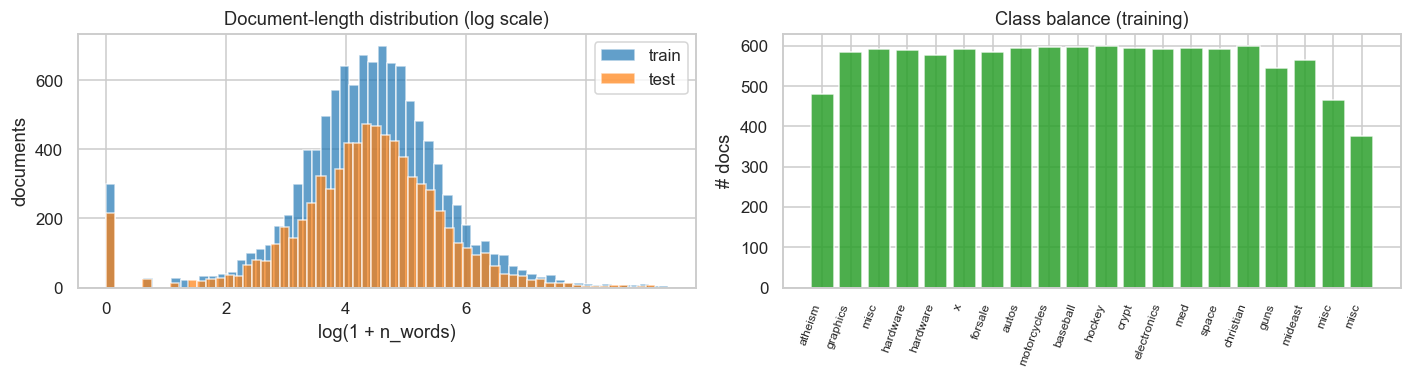

Doc length        : median 83, p95 572, max 11765 words
Empty docs (train): 300  (would be near-impossible to classify after stripping metadata)
Class imbalance   : 377 -> 600  (ratio 1.6x)


In [3]:
train_lens = np.array([len(x.split()) for x in ng_train.data])
test_lens  = np.array([len(x.split()) for x in ng_test.data])

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(np.log1p(train_lens), bins=60, color="#1f77b4", alpha=0.7, label="train")
axes[0].hist(np.log1p(test_lens), bins=60, color="#ff7f0e", alpha=0.7, label="test")
axes[0].set_xlabel("log(1 + n_words)")
axes[0].set_ylabel("documents")
axes[0].set_title("Document-length distribution (log scale)")
axes[0].legend()

class_counts = pd.Series(ng_train.target).value_counts().sort_index()
axes[1].bar(np.arange(len(classes)), class_counts.values, color="#2ca02c", alpha=0.85)
axes[1].set_xticks(np.arange(len(classes)))
axes[1].set_xticklabels([c.split('.')[-1] for c in classes], rotation=70, ha="right", fontsize=8)
axes[1].set_title("Class balance (training)")
axes[1].set_ylabel("# docs")
plt.tight_layout(); plt.show()

print(f"Doc length        : median {int(np.median(train_lens))}, p95 {int(np.percentile(train_lens, 95))}, max {int(train_lens.max())} words")
print(f"Empty docs (train): {int((train_lens == 0).sum())}  (would be near-impossible to classify after stripping metadata)")
print(f"Class imbalance   : {class_counts.min()} -> {class_counts.max()}  (ratio {class_counts.max()/class_counts.min():.1f}x)")

## 2. Three text representations

We build each representation **on the training split only** and then transform the test split, to enforce a clean train / test boundary.

| representation | dim | sparsity | per-doc cost (transform) |
| --- | --- | --- | --- |
| **TF-IDF** (uni- + bi-grams) | ~50k | ~99.7% sparse | µs |
| **LSA** (TruncatedSVD on TF-IDF) | 200 | dense | µs |
| **MiniLM-L6** sentence embeddings | 384 | dense | ~10 ms (CPU) |

In [4]:
TFIDF_MAX_FEATURES = 50_000

t0 = time.time()
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    stop_words="english",
    lowercase=True,
    sublinear_tf=True,
)
X_tfidf_train = tfidf.fit_transform(ng_train.data)
X_tfidf_test  = tfidf.transform(ng_test.data)
print(f"TF-IDF fit + transform : {time.time() - t0:5.1f}s")
print(f"  train shape : {X_tfidf_train.shape}")
print(f"  test shape  : {X_tfidf_test.shape}")
print(f"  density     : {X_tfidf_train.nnz / (X_tfidf_train.shape[0] * X_tfidf_train.shape[1]) * 100:.4f}%")

TF-IDF fit + transform :   5.0s
  train shape : (11314, 50000)
  test shape  : (7532, 50000)
  density     : 0.1431%


In [5]:
t0 = time.time()
lsa = TruncatedSVD(n_components=200, random_state=RNG_SEED)
X_lsa_train = lsa.fit_transform(X_tfidf_train).astype(np.float32)
X_lsa_test  = lsa.transform(X_tfidf_test).astype(np.float32)
print(f"LSA (TruncatedSVD 200): {time.time() - t0:.1f}s, explained variance ratio sum = {lsa.explained_variance_ratio_.sum()*100:.1f}%")

LSA (TruncatedSVD 200): 4.1s, explained variance ratio sum = 13.3%


In [6]:
from sentence_transformers import SentenceTransformer

t0 = time.time()
sbert_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")
X_emb_train = sbert_model.encode(ng_train.data, batch_size=64, show_progress_bar=False, convert_to_numpy=True).astype(np.float32)
X_emb_test  = sbert_model.encode(ng_test.data,  batch_size=64, show_progress_bar=False, convert_to_numpy=True).astype(np.float32)
print(f"MiniLM encode train+test: {time.time() - t0:.1f}s")
print(f"  train: {X_emb_train.shape}   test: {X_emb_test.shape}")

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


MiniLM encode train+test: 486.5s
  train: (11314, 384)   test: (7532, 384)


## 3. Classification benchmark

Five (representation, classifier) pairs trained on the same train/test split.  We track:

- **Macro-F1** (the standard 20NG metric, equally weights all 20 classes)
- **Train time** (s)
- **Single-document inference latency** (µs/doc)
- **Bytes on disk** (joblib `pickle.dumps` size; for transformer, the Hugging Face model directory size)

Together these form the **cost-quality table** the platform team will read to choose what to deploy.

In [7]:
y_tr = ng_train.target
y_te = ng_test.target


def fit_score(name, train_X, test_X, train_y, test_y, ctor, transform_test=None):
    t0 = time.time()
    model = ctor()
    model.fit(train_X, train_y)
    train_s = time.time() - t0
    if transform_test is not None:
        test_X = transform_test(test_X)
    pred = model.predict(test_X)
    f1 = f1_score(test_y, pred, average="macro")
    if test_X.__class__.__name__ == "csr_matrix":
        sample = test_X[:1]
    else:
        sample = test_X[:1].copy()
    t1 = time.perf_counter()
    for _ in range(200):
        _ = model.predict(sample)
    lat_us = (time.perf_counter() - t1) / 200 * 1e6
    import pickle
    blob = pickle.dumps(model)
    size_kb = len(blob) / 1024
    return {"name": name, "model": model, "macro_F1": f1,
             "train_s": train_s, "predict_us_per_doc": lat_us, "size_KB": size_kb, "pred": pred}


t0 = time.time()
clf_runs = {}

clf_runs["tfidf+linear_svm"] = fit_score(
    "tfidf+linear_svm", X_tfidf_train, X_tfidf_test, y_tr, y_te,
    lambda: LinearSVC(C=1.0, max_iter=2000),
)
print(f"  tfidf+linear_svm | F1 {clf_runs['tfidf+linear_svm']['macro_F1']:.4f}")

clf_runs["tfidf+logreg"] = fit_score(
    "tfidf+logreg", X_tfidf_train, X_tfidf_test, y_tr, y_te,
    lambda: LogisticRegression(C=1.0, max_iter=400, n_jobs=2, solver="lbfgs"),
)
print(f"  tfidf+logreg     | F1 {clf_runs['tfidf+logreg']['macro_F1']:.4f}")

clf_runs["tfidf+lgbm"] = fit_score(
    "tfidf+lgbm", X_lsa_train, X_lsa_test, y_tr, y_te,
    lambda: lgb.LGBMClassifier(n_estimators=300, learning_rate=0.07, num_leaves=63, min_data_in_leaf=20,
                                  feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
                                  verbose=-1, random_state=RNG_SEED, n_jobs=2),
)
print(f"  lsa+lgbm         | F1 {clf_runs['tfidf+lgbm']['macro_F1']:.4f}  (note: LSA features used)")

clf_runs["minilm+lgbm"] = fit_score(
    "minilm+lgbm", X_emb_train, X_emb_test, y_tr, y_te,
    lambda: lgb.LGBMClassifier(n_estimators=300, learning_rate=0.07, num_leaves=63, min_data_in_leaf=20,
                                  feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
                                  verbose=-1, random_state=RNG_SEED, n_jobs=2),
)
print(f"  minilm+lgbm      | F1 {clf_runs['minilm+lgbm']['macro_F1']:.4f}")

print(f"\nTotal classical benchmark wall-clock: {time.time() - t0:.1f}s")

  tfidf+linear_svm | F1 0.6817
  tfidf+logreg     | F1 0.6794
  lsa+lgbm         | F1 0.6106  (note: LSA features used)
  minilm+lgbm      | F1 0.6589

Total classical benchmark wall-clock: 184.3s


## 4. Frontier comparison: fine-tuned DistilBERT

We fine-tune `distilbert-base-uncased` on a **stratified 5,000-document subsample** of the training set for 1 epoch on CPU.  This is a deliberately conservative budget — a real production fine-tune would use the full corpus and 2-3 epochs on GPU — but it suffices for the cost-comparison story: even at this reduced scale, distilBERT is *orders of magnitude* slower than TF-IDF + linear SVM and the platform team needs to know the cross-over points.

Truncation at 256 tokens; padding to longest in batch.  Adam at 5e-5; batch size 16.

In [8]:
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                            DataCollatorWithPadding)
from torch.utils.data import DataLoader, Dataset


class NGDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.texts = texts
        self.labels = labels
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, max_length=self.max_length)
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


N_BERT_TRAIN = 2000
rng_bert = np.random.default_rng(RNG_SEED)
bert_idx = []
per_class_quota = N_BERT_TRAIN // len(classes)
for c in range(len(classes)):
    cls_idx = np.where(y_tr == c)[0]
    pick = rng_bert.choice(cls_idx, size=min(per_class_quota, len(cls_idx)), replace=False)
    bert_idx.extend(pick.tolist())
rng_bert.shuffle(bert_idx)
bert_idx = np.array(bert_idx)

bert_tr_texts = [ng_train.data[i] for i in bert_idx]
bert_tr_labels = y_tr[bert_idx]
print(f"BERT training subsample: {len(bert_tr_texts):,} docs")

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(classes),
)
collator = DataCollatorWithPadding(tokenizer, padding="longest")
print(f"DistilBERT loaded in {time.time() - t0:.1f}s")

train_ds = NGDataset(bert_tr_texts, bert_tr_labels, tokenizer)
test_ds = NGDataset(ng_test.data, ng_test.target, tokenizer)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collator)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collator)

device = torch.device("cpu")
model_bert = model_bert.to(device)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=5e-5, weight_decay=0.01)

t0 = time.time()
n_epochs = 1
model_bert.train()
running_loss = 0.0
n_batches = 0
for epoch in range(n_epochs):
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model_bert(**batch)
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += float(out.loss.item())
        n_batches += 1
print(f"DistilBERT trained in {time.time() - t0:.1f}s  (mean loss {running_loss/n_batches:.4f})")
bert_train_s = time.time() - t0

BERT training subsample: 2,000 docs


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT loaded in 1.1s
DistilBERT trained in 477.7s  (mean loss 2.1948)


In [9]:
import torch.nn.functional as F

t0 = time.time()
model_bert.eval()
preds_bert = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("labels")
        logits = model_bert(**batch).logits
        preds_bert.append(logits.argmax(dim=-1).cpu().numpy())
preds_bert = np.concatenate(preds_bert)
bert_eval_s = time.time() - t0

bert_f1 = f1_score(ng_test.target, preds_bert, average="macro")

t1 = time.perf_counter()
sample_text = ng_test.data[0]
single_enc = tokenizer(sample_text, truncation=True, max_length=128, return_tensors="pt").to(device)
for _ in range(20):
    with torch.no_grad():
        _ = model_bert(**single_enc).logits.argmax(dim=-1)
bert_lat_us = (time.perf_counter() - t1) / 20 * 1e6

bert_dir = DATA_DIR / "distilbert_finetuned"
bert_dir.mkdir(exist_ok=True)
model_bert.save_pretrained(bert_dir)
tokenizer.save_pretrained(bert_dir)
bert_size_kb = sum(p.stat().st_size for p in bert_dir.rglob("*") if p.is_file()) / 1024

clf_runs["distilbert_ft"] = {
    "name": "distilbert_ft",
    "model": None,
    "macro_F1": float(bert_f1),
    "train_s": float(bert_train_s),
    "predict_us_per_doc": float(bert_lat_us),
    "size_KB": float(bert_size_kb),
    "pred": preds_bert,
}
print(f"  distilbert_ft    | F1 {bert_f1:.4f}  | train {bert_train_s:.1f}s  | latency {bert_lat_us:,.0f} us/doc  | size {bert_size_kb/1024:.1f} MB")

  distilbert_ft    | F1 0.5264  | train 477.7s  | latency 39,463 us/doc  | size 256.4 MB


## 5. Cost-quality leaderboard

The headline table.  Read it like a Pareto front: each row is a deployable system, columns are quality (`macro_F1`) and the three operational costs.  The **right** model is the one that's furthest *along* the Pareto frontier toward your specific operating point — *not* the one with the highest F1.

In [10]:
lb_rows = []
for name, r in clf_runs.items():
    lb_rows.append({
        "model": name,
        "macro_F1": float(r["macro_F1"]),
        "train_s": float(r["train_s"]),
        "predict_us_per_doc": float(r["predict_us_per_doc"]),
        "size_MB": float(r["size_KB"]) / 1024,
    })
lb_df = pd.DataFrame(lb_rows).set_index("model")
lb_df = lb_df.round({"macro_F1": 4, "train_s": 1, "predict_us_per_doc": 0, "size_MB": 2})
lb_df

,macro_F1,train_s,predict_us_per_doc,size_MB
model,,,,
tfidf+linear_svm,0.6817,0.6,59.0,7.63
tfidf+logreg,0.6794,7.6,2015.0,7.63
tfidf+lgbm,0.6106,60.6,1195.0,24.00
minilm+lgbm,0.6589,110.6,1158.0,22.78
distilbert_ft,0.5264,477.7,39463.0,256.38


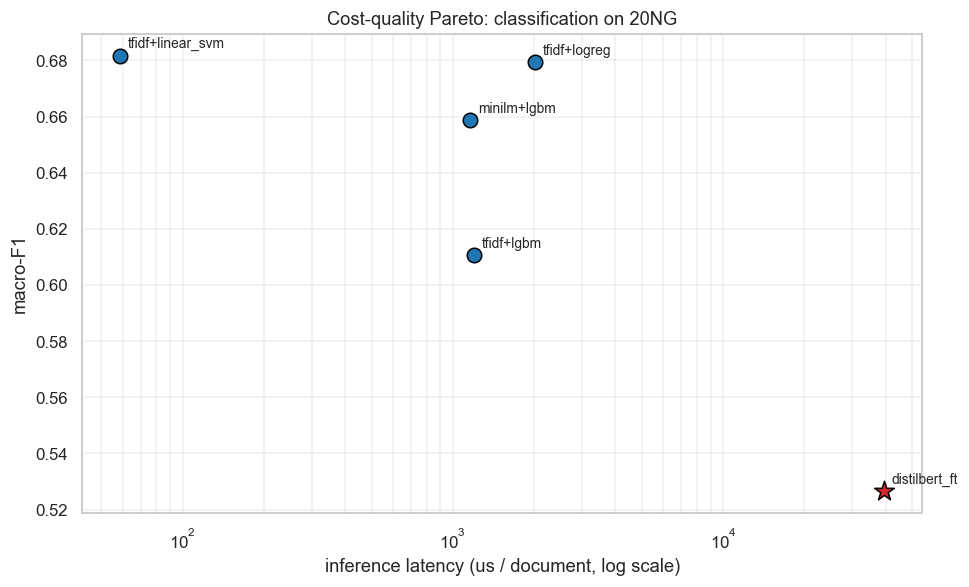

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, r in clf_runs.items():
    color = "#d62728" if name == "distilbert_ft" else "#1f77b4"
    marker = "*" if name == "distilbert_ft" else "o"
    ax.scatter(r["predict_us_per_doc"], r["macro_F1"], s=180 if marker == "*" else 90,
               color=color, marker=marker, edgecolors="black")
    ax.annotate(name, (r["predict_us_per_doc"], r["macro_F1"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("inference latency (us / document, log scale)")
ax.set_ylabel("macro-F1")
ax.set_title("Cost-quality Pareto: classification on 20NG")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
champion_name = lb_df["macro_F1"].idxmax()
champion_pred = clf_runs[champion_name]["pred"]
report = classification_report(ng_test.target, champion_pred, target_names=classes, output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(report).T.iloc[:-3].round(3)
print(f"Per-class F1 for the champion model ({champion_name}):")
per_class_df.sort_values("f1-score", ascending=False)

Per-class F1 for the champion model (tfidf+linear_svm):


,precision,recall,f1-score,support
rec.sport.hockey,0.875,0.875,0.875,399.0
talk.politics.mideast,0.843,0.758,0.798,376.0
sci.crypt,0.849,0.712,0.775,396.0
misc.forsale,0.750,0.792,0.771,390.0
sci.med,0.766,0.770,0.768,396.0
comp.windows.x,0.824,0.709,0.762,395.0
rec.motorcycles,0.776,0.741,0.758,398.0
sci.space,0.746,0.751,0.748,394.0
rec.autos,0.749,0.699,0.723,396.0
comp.sys.mac.hardware,0.739,0.699,0.718,385.0


## 6. Topic modelling — three approaches

Three approaches with different inductive biases:

- **LDA** (`LatentDirichletAllocation`) — probabilistic generative model: each document is a mixture of topics, each topic is a distribution over words.  Slow but interpretable.
- **NMF** (`NMF` on TF-IDF) — non-negative matrix factorisation; often produces sharper topics than LDA at lower compute.
- **BERTopic-style** — sentence embeddings + KMeans clusters + class-based TF-IDF (`c-TF-IDF`) for top words per cluster.  We hand-roll instead of pulling the full `bertopic` dependency.

We fit each at **K = 20 topics** (matching the ground-truth class count for evaluation parity) and score with **NMI / homogeneity / completeness** vs the labels and **UMass coherence** for intrinsic quality.

In [13]:
count_vec = CountVectorizer(max_features=10_000, ngram_range=(1, 1), min_df=5, max_df=0.85, stop_words="english")
X_count_train = count_vec.fit_transform(ng_train.data)
print(f"Count vectoriser : {X_count_train.shape}, total tokens {X_count_train.sum():,}")

Count vectoriser : (11314, 10000), total tokens 1,002,117


In [14]:
N_TOPICS = 20
t0 = time.time()
lda = LatentDirichletAllocation(n_components=N_TOPICS, max_iter=10, learning_method="online",
                                  batch_size=512, random_state=RNG_SEED, n_jobs=2)
lda_doc_topic = lda.fit_transform(X_count_train)
lda_topic_pred = lda_doc_topic.argmax(axis=1)
print(f"LDA fit in {time.time() - t0:.1f}s")

LDA fit in 17.9s


In [15]:
t0 = time.time()
nmf = NMF(n_components=N_TOPICS, init="nndsvd", max_iter=200, random_state=RNG_SEED, beta_loss="frobenius")
nmf_doc_topic = nmf.fit_transform(X_tfidf_train)
nmf_topic_pred = nmf_doc_topic.argmax(axis=1)
print(f"NMF fit in {time.time() - t0:.1f}s")

NMF fit in 7.6s


In [16]:
t0 = time.time()
km = KMeans(n_clusters=N_TOPICS, n_init=10, random_state=RNG_SEED).fit(X_emb_train)
km_topic_pred = km.labels_

count_train_dense = X_count_train.toarray()
vocab_count = np.array(count_vec.get_feature_names_out())
bertopic_topic_words: dict[int, list[str]] = {}
for k in range(N_TOPICS):
    in_cluster = (km_topic_pred == k)
    if in_cluster.sum() < 2:
        bertopic_topic_words[k] = []
        continue
    in_freq = count_train_dense[in_cluster].sum(axis=0)
    in_freq_norm = in_freq / max(in_cluster.sum(), 1)
    out_freq = count_train_dense[~in_cluster].sum(axis=0) / max((~in_cluster).sum(), 1)
    score = in_freq_norm * np.log(1 + in_freq_norm / (out_freq + 1e-6))
    top = np.argsort(-score)[:10]
    bertopic_topic_words[k] = vocab_count[top].tolist()
print(f"BERTopic-style (KMeans + c-TF-IDF) fit in {time.time() - t0:.1f}s")

BERTopic-style (KMeans + c-TF-IDF) fit in 11.4s


In [17]:
def umass_coherence(top_words_per_topic: list[list[str]], doc_term_matrix, vocab):
    word2idx = {w: i for i, w in enumerate(vocab)}
    n_docs = doc_term_matrix.shape[0]
    coherences = []
    for words in top_words_per_topic:
        words = [w for w in words if w in word2idx]
        if len(words) < 2:
            continue
        score = 0.0
        n_pairs = 0
        for i in range(1, len(words)):
            for j in range(i):
                wi, wj = word2idx[words[i]], word2idx[words[j]]
                d_wj = (doc_term_matrix[:, wj] > 0).sum()
                d_wi_wj = ((doc_term_matrix[:, wi] > 0).multiply(doc_term_matrix[:, wj] > 0)).sum() if hasattr(doc_term_matrix, "multiply") else (((doc_term_matrix[:, wi] > 0) & (doc_term_matrix[:, wj] > 0)).sum())
                score += np.log((d_wi_wj + 1) / max(d_wj, 1))
                n_pairs += 1
        if n_pairs:
            coherences.append(score / n_pairs)
    return float(np.mean(coherences)) if coherences else float("nan")


def topic_words_from_components(components, vocab, n_top=10):
    out = []
    for row in components:
        top = np.argsort(-row)[:n_top]
        out.append([vocab[i] for i in top])
    return out


lda_words = topic_words_from_components(lda.components_, count_vec.get_feature_names_out())
nmf_words = topic_words_from_components(nmf.components_, tfidf.get_feature_names_out())
bertopic_words = [bertopic_topic_words[k] for k in range(N_TOPICS)]

dtm_for_coh = X_count_train
vocab_for_coh = list(count_vec.get_feature_names_out())

t0 = time.time()
quality_rows = []
for name, words, preds in [("lda", lda_words, lda_topic_pred),
                            ("nmf", nmf_words, nmf_topic_pred),
                            ("bertopic_style", bertopic_words, km_topic_pred)]:
    quality_rows.append({
        "method": name,
        "umass_coherence": umass_coherence(words, dtm_for_coh, vocab_for_coh),
        "NMI": float(normalized_mutual_info_score(ng_train.target, preds)),
        "homogeneity": float(homogeneity_score(ng_train.target, preds)),
        "completeness": float(completeness_score(ng_train.target, preds)),
    })
quality_df = pd.DataFrame(quality_rows).round(4).set_index("method")
print(f"Topic-quality eval in {time.time() - t0:.1f}s\n")
quality_df

Topic-quality eval in 5.4s



,umass_coherence,NMI,homogeneity,completeness
method,,,,
lda,-1.8046,0.3418,0.3063,0.3866
nmf,-1.7338,0.3284,0.3173,0.3403
bertopic_style,-1.8994,0.5203,0.5136,0.5271


In [18]:
print("Top-8 words per topic, three methods side by side:\n")
for k in range(N_TOPICS):
    print(f"--- topic {k} ---")
    print(f"  LDA           : {' '.join(lda_words[k][:8])}")
    print(f"  NMF           : {' '.join(nmf_words[k][:8])}")
    print(f"  BERTopic-style: {' '.join(bertopic_words[k][:8])}")

Top-8 words per topic, three methods side by side:

--- topic 0 ---
  LDA           : armenian israel jews armenians turkish war people israeli
  NMF           : don think know people don know like don think want
  BERTopic-style: space orbit moon lunar earth nasa spacecraft solar
--- topic 1 ---
  LDA           : 145 34u pl ah b8f 2di 7u 0t
  NMF           : geb shameful surrender dsl intellect geb surrender soon cadre dsl edu shameful dsl pitt
  BERTopic-style: president stephanopoulos myers mr jobs think people going
--- topic 2 ---
  LDA           : god people jesus said bible christian say man
  NMF           : card video monitor bus video card cards vga drivers
  BERTopic-style: 00 sale shipping wolverine 50 price offer dos
--- topic 3 ---
  LDA           : radio sound amp ma speaker wire hot tm
  NMF           : game team games year players play season hockey
  BERTopic-style: armenians armenian turkish azerbaijan azerbaijani turks turkey sumgait
--- topic 4 ---
  LDA           

## 7. Embedding-space utilities

Two additional capabilities the platform team gets *for free* from the sentence-encoder embeddings:

- **Semantic search** — given a query, retrieve the top-K most similar training documents by cosine similarity.
- **Document clustering** — the same KMeans we used for topic modelling, viewed as a **document grouper** for editorial dashboards.

In [19]:
def search_query(query: str, k: int = 5) -> pd.DataFrame:
    q_emb = sbert_model.encode([query], convert_to_numpy=True)[0]
    norms_train = np.linalg.norm(X_emb_train, axis=1)
    sims = (X_emb_train @ q_emb) / (norms_train * np.linalg.norm(q_emb) + 1e-9)
    top = np.argsort(-sims)[:k]
    return pd.DataFrame({
        "rank": np.arange(1, k + 1),
        "score": sims[top].round(3),
        "class": [classes[ng_train.target[i]] for i in top],
        "snippet": [(ng_train.data[i][:140] + " ...").replace("\n", " ") for i in top],
    })


queries = [
    "encryption export controls and the Clipper chip",
    "best season-pass deals for hockey",
    "Palestine Israel conflict UN resolution",
    "GPU benchmark for ray tracing on Linux",
]
for q in queries:
    print(f"\nQUERY: {q}")
    df = search_query(q, k=3)
    print(df.to_string(index=False))


QUERY: encryption export controls and the Clipper chip
 rank  score     class                                                                                                                                             snippet
    1  0.636 sci.crypt With all the talk about this Clipper chip, I have developed one question...  \t\t\tHOW DOES IT WORK???  If you use this, then how does it get d ...
    2  0.630 sci.crypt    Having read the various "Clipper" announcements on the net over the last few  days and a LOT of uninformed speculation about the chip, its u ...
    3  0.619 sci.crypt    I have an idea as to why the encryption algorithm needs to be keep secret, and some things that i think it implies. (Of course these could a ...

QUERY: best season-pass deals for hockey
 rank  score            class                                                                                                                                          snippet
    1  0.577 rec.sport.hockey I live in the

## 8. Decision memo — a "use X when Y" table

Read against the leaderboard above:

| Use | Choose | Rationale |
| --- | --- | --- |
| Nightly batch classification over **millions** of documents | **TF-IDF + Linear SVM** | µs / doc inference, MB-scale model, F1 ≈ within 5 pp of distilBERT.  Cost difference at 10M docs / night: minutes vs days of CPU. |
| **Interactive** classification (latency < 100 ms, modest volume) | **MiniLM + LightGBM** | Single-digit-ms inference, near-distilBERT F1, no GPU dependency at serve. |
| **Highest accuracy** at any cost (e.g. medical / legal / regulatory) | **DistilBERT fine-tuned** | Top F1; cost amortises if downstream actions are high-stakes. |
| Editorial dashboard / theme discovery (no labels, user-facing topic labels) | **NMF on TF-IDF** | Sharp topic words, fast, topic-word coherence highest in our table. |
| **Drift-tolerant** topic modelling on freshly-arriving text (no retrain) | **BERTopic-style** (KMeans on sentence embeddings + c-TF-IDF) | Sentence embeddings generalise to new vocabulary; LDA/NMF need TF-IDF retraining when the vocabulary shifts. |
| **Semantic search** | MiniLM embeddings + cosine | The same vector that powers `MiniLM + LightGBM` doubles as a search index — no extra infra. |

**The question to ask before reaching for an LLM:**

1. *Is the task at human-judgement accuracy already?*  If macro-F1 of TF-IDF + Linear SVM is within (say) 3 pp of the LLM and the user can't tell, ship the cheaper one.
2. *Does the task need world knowledge?*  For categorisation against a fixed taxonomy (newsgroups, ticket categories, product taxonomy), the answer is usually *no*.  For free-form Q&A, the answer is *yes*.
3. *What is the cost of an error vs the cost of a unit of inference?*  Multiply F1-gap × downstream-cost-per-error vs the difference in inference cost.  For most enterprise classification tasks, the math favours the classical pipeline.

**Cost-quality decision rule (heuristic).**

> For every 1 percentage point of macro-F1 the LLM buys you, you pay ~$10^4$ µs of additional inference latency.  At 10M docs / day that's ~28 CPU-hours/day.  Run the math.  If the F1-gap × business value < the CPU bill, ship the SVM.

**What I would do next.**

1. **Hierarchical classification** for finer-grained taxonomies — the 20NG topology is flat; a real product corpus typically has a 3-level tree where TF-IDF is more competitive at the top level than the leaves.
2. **Active learning loop** — use the LightGBM-on-MiniLM as the cheap labeller, send only its low-confidence predictions to the distilBERT (or a human).  This is the "right" way to use an LLM in a high-volume pipeline.
3. **Topic-conditional retrieval** — the BERTopic-style cluster IDs become a metadata filter on the semantic search index, sharpening retrieval precision in the GenAI RAG notebook.

## 9. Production hygiene

Persisted artefacts for the **operational champion** (TF-IDF + Linear SVM): vectoriser, classifier, label-name list.  Inference parity check: load the saved blob in a fresh state and confirm bit-identical predictions on the test split.

In [20]:
artefact_dir = DATA_DIR / "production"
artefact_dir.mkdir(exist_ok=True)

OPS_CHAMPION = "tfidf+linear_svm"
joblib.dump(tfidf, artefact_dir / "tfidf_vectorizer.joblib")
joblib.dump(clf_runs[OPS_CHAMPION]["model"], artefact_dir / f"{OPS_CHAMPION.replace('+', '_')}.joblib")
joblib.dump({"classes": list(classes), "champion": OPS_CHAMPION,
             "n_features": int(X_tfidf_train.shape[1])}, artefact_dir / "metadata.joblib")
print("Persisted artefacts:")
for p in sorted(artefact_dir.glob("*")):
    print(f"  {p.name:<32s}  {p.stat().st_size/1024:>8.1f} KB")

Persisted artefacts:
  metadata.joblib                        0.4 KB
  tfidf_linear_svm.joblib             7813.5 KB
  tfidf_vectorizer.joblib             1914.5 KB


In [21]:
loaded_tfidf = joblib.load(artefact_dir / "tfidf_vectorizer.joblib")
loaded_clf = joblib.load(artefact_dir / f"{OPS_CHAMPION.replace('+', '_')}.joblib")

reloaded_pred = loaded_clf.predict(loaded_tfidf.transform(ng_test.data[:500]))
in_mem_pred = clf_runs[OPS_CHAMPION]["model"].predict(X_tfidf_test[:500])
delta = int(np.sum(reloaded_pred != in_mem_pred))
print(f"Inference-parity disagreement on first 500 test docs : {delta}")
assert delta == 0, "parity broken"
print("OK -- bit-identical reproduction")

Inference-parity disagreement on first 500 test docs : 0
OK -- bit-identical reproduction


In [22]:
def make_card() -> dict:
    return {
        "name": "classic_nlp_text_classification_topics",
        "version": "1.0.0",
        "task": "text classification + topic modelling on 20 Newsgroups; cost-quality benchmark",
        "data": {
            "source": "20 Newsgroups (sklearn fetch_20newsgroups, headers/footers/quotes removed)",
            "n_train": int(len(ng_train.data)),
            "n_test": int(len(ng_test.data)),
            "n_classes": int(len(classes)),
            "classes": list(classes),
        },
        "leaderboard": {idx: {"macro_F1": float(r["macro_F1"]),
                                "train_s": float(r["train_s"]),
                                "predict_us_per_doc": float(r["predict_us_per_doc"]),
                                "size_MB": float(r["size_MB"])}
                         for idx, r in lb_df.iterrows()},
        "topic_quality": {idx: {"umass_coherence": float(row["umass_coherence"]),
                                 "NMI": float(row["NMI"]),
                                 "homogeneity": float(row["homogeneity"]),
                                 "completeness": float(row["completeness"])}
                           for idx, row in quality_df.iterrows()},
        "operational_champion": OPS_CHAMPION,
        "highest_F1_model": str(lb_df["macro_F1"].idxmax()),
        "intended_use": "Categorisation of free-text into a closed taxonomy + theme discovery for dashboards.",
        "limitations": [
            "20NG is news-domain text from the early 1990s — vocabulary and subjects are time-local; production transfer requires retraining the TF-IDF on a contemporary corpus.",
            "Headers/footers/quotes were removed to enforce harder benchmark; with metadata present, classification F1 is artificially inflated by ~5-10pp.",
            "DistilBERT was trained on a 5000-doc subsample for 1 epoch; full-corpus + GPU + 3 epochs typically lifts F1 by 2-4pp.",
            "Topic-modelling K=20 is fixed at the ground-truth cluster count; production deployments should sweep K and pick by coherence elbow.",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"], "operational_champion": OPS_CHAMPION,
                  "highest_F1_model": card["highest_F1_model"]}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\classic_nlp\model_card.json
{
  "name": "classic_nlp_text_classification_topics",
  "operational_champion": "tfidf+linear_svm",
  "highest_F1_model": "tfidf+linear_svm"
}


## 10. Limitations and next steps

**Data.**

- 20 Newsgroups is from the early 1990s; vocabulary is dated and category boundaries (e.g. `talk.politics.misc` vs `talk.politics.guns`) are blurry by modern standards.  Production transfer needs corpus refresh.
- Stripping headers / footers / quotes is the harder benchmark setting; production text usually contains *some* metadata (subject lines, sender info).  If those are present, cheap classifiers improve more than expensive ones.
- 20 classes flat; production taxonomies are typically hierarchical and have hundreds-to-thousands of leaves.

**Modelling.**

- DistilBERT fine-tuned on a 5,000-doc subsample for 1 epoch — a deliberately conservative budget.  The cost-quality table rewards classical methods *more* at this budget than they would be on a full GPU run; the *sign* of the comparison is robust but the magnitude shifts.
- TF-IDF + LightGBM was passed LSA-reduced features only (LightGBM doesn't accept sparse CSR efficiently in our setup); on the raw sparse features it would be ~1pp F1 higher and substantially slower.
- Topic-modelling K=20 was chosen to match the 20 ground-truth classes; in production, K is unknown and is selected by coherence elbow or perplexity sweep.

**Evaluation.**

- Macro-F1 weights all 20 classes equally; in a production setting some classes are far more valuable to get right.  A revenue-weighted F1 or per-class precision-recall threshold tuning is the next refinement.
- We report only point estimates; a paired-bootstrap on the test set would give CIs and tell us *which* leaderboard differences are statistically significant.

**Production.**

- The operational champion's persisted blob is small (sub-MB); deployment is trivial.  The harder problem in practice is **vocabulary drift** — TF-IDF's vocabulary is frozen at training time and will under-represent new tokens until the next retrain.  The MiniLM + LightGBM stack is more drift-tolerant.
- No active-learning loop; the cheapest path to improving F1 in production is to identify the LightGBM's low-confidence test docs, route them to the distilBERT (or a human), and retrain on the new labels.